In [ ]:
import os.path as path
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #

ROOT = "../sym_graphs/data_io/results_k2"

# Same conversion as your previous plot:
# 10 simulation steps -> 5 microseconds, hence 1 step -> 0.5 microseconds.
DT_US = 0.5

# Numerical tolerance for deciding whether two graphs are separated
TOL = 1e-8

FAMILIES = [
    {
        "prefix": "srg25",
        "n_graphs": 15,
        "color": "seagreen",
        "title": r"$srg(25,12,5,6)$",
        "xlabel": "(a)",
    },
    {
        "prefix": "srg26",
        "n_graphs": 10,
        "color": "darkorchid",
        "title": r"$srg(26,10,3,4)$",
        "xlabel": "(b)",
    },
]

# --------------------------------------------------------------------------- #
# Loading
# --------------------------------------------------------------------------- #

def load_node_occupations(prefix, n_graphs, root=ROOT):
    """
    Load node occupations for one SRG family.

    Returns
    -------
    diags : np.ndarray, shape (G, T, N)
        diags[g, t, u] = <n_u>(t) for graph g at time t.
    """
    diags = np.stack(
        [
            np.load(path.join(root, f"C_{prefix}_{k}_k2.npy")).diagonal(
                axis1=1,
                axis2=2,
            )
            for k in range(n_graphs)
        ],
        axis=0,
    )
    return diags

# --------------------------------------------------------------------------- #
# Permutation-invariant graph distance
# --------------------------------------------------------------------------- #

def cumulative_assignment_distance_curve(A, B):
    """
    Compute the permutation-invariant node-trajectory distance curve
    between two graphs.

    Parameters
    ----------
    A, B : np.ndarray, shape (T, N)
        Node occupation trajectories of two graphs.

    Returns
    -------
    curve : np.ndarray, shape (T,)
        curve[t] is the optimal assignment RMS distance between node
        trajectories restricted to times 0, ..., t.

    Meaning
    -------
    For each time cutoff t, this computes

        min_pi sqrt(
            mean_u mean_{tau <= t}
            | <n_u>_A(tau) - <n_{pi(u)}>_B(tau) |^2
        )

    where the minimum over pi is solved with the Hungarian algorithm.
    """
    T, N = A.shape

    # diff[t, u, v] = occupation difference between node u of A and node v of B
    diff = A[:, :, None] - B[:, None, :]  # shape (T, N, N)

    # cumulative squared discrepancies up to each time
    cum_sq = np.cumsum(diff**2, axis=0)

    curve = np.zeros(T)

    for t in range(T):
        # cost_sq[u, v] = mean squared discrepancy between node trajectory u and v
        # over time steps 0, ..., t
        cost_sq = cum_sq[t] / (t + 1)

        # Find the best vertex matching
        row_ind, col_ind = linear_sum_assignment(cost_sq)

        # RMS distance under the optimal matching
        curve[t] = np.sqrt(cost_sq[row_ind, col_ind].mean())

    return curve


def compute_family_assignment_curves(prefix, n_graphs, root=ROOT):
    """
    Compute all pairwise permutation-invariant distance curves for one SRG family.
    """
    diags = load_node_occupations(prefix, n_graphs, root=root)

    G, T, N = diags.shape
    graph_pairs = list(itertools.combinations(range(G), 2))

    pair_curves = np.zeros((len(graph_pairs), T))

    for p, (i, j) in enumerate(graph_pairs):
        pair_curves[p] = cumulative_assignment_distance_curve(diags[i], diags[j])

    mean_curve = pair_curves.mean(axis=0)
    std_curve = pair_curves.std(axis=0)
    min_curve = pair_curves.min(axis=0)

    final_distances = pair_curves[:, -1]
    worst_idx = np.argmin(final_distances)
    worst_pair = graph_pairs[worst_idx]
    worst_distance = final_distances[worst_idx]

    all_separated = np.all(final_distances > TOL)

    return {
        "diags": diags,
        "graph_pairs": graph_pairs,
        "pair_curves": pair_curves,
        "mean_curve": mean_curve,
        "std_curve": std_curve,
        "min_curve": min_curve,
        "final_distances": final_distances,
        "worst_pair": worst_pair,
        "worst_distance": worst_distance,
        "all_separated": all_separated,
        "G": G,
        "T": T,
        "N": N,
    }

# --------------------------------------------------------------------------- #
# Plotting
# --------------------------------------------------------------------------- #

def plot_assignment_distance_curves(
    results_by_family,
    save_path="figures/srg_assignment_distance_curves.pdf",
):
    """
    Plot one panel per SRG family, in the same style as your previous figure.
    """
    # Close any stale figures left over from previous cells so a previously
    # broken figure cannot keep re-rendering and raising on redraw.
    plt.close("all")

    plt.rcParams.update(
        {
            "font.size": 16,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": False,
            "grid.alpha": 0.25,
            "figure.dpi": 130,
        }
    )

    fig, axes = plt.subplots(1, len(FAMILIES), figsize=(10, 2.5))

    if len(FAMILIES) == 1:
        axes = [axes]

    for ax, fam in zip(axes, FAMILIES):
        res = results_by_family[fam["prefix"]]

        T = res["T"]
        t_us = DT_US * np.arange(T)

        color = fam["color"]
        mean_curve = res["mean_curve"]
        std_curve = res["std_curve"]
        min_curve = res["min_curve"]

        # Mean over graph pairs
        ax.plot(
            t_us,
            mean_curve,
            color=color,
            lw=1.8,
            label=r"$\bar{\eta}^{(1)}(t) \leftarrow $ " + fam["title"],
        )

        # +/- 1 std over graph pairs
        ax.fill_between(
            t_us,
            np.maximum(mean_curve - std_curve, 0.0),
            mean_curve + std_curve,
            color=color,
            alpha=0.20,
            linewidth=0,
        )

        # Minimum over graph pairs: most important curve for separability
        ax.plot(
            t_us,
            min_curve,
            color="k",
            lw=1.6,
            ls="--",
            label=r"$\min_{i<j}\,\eta^{(1)}_{ij}(t)$",
        )

        # Horizontal numerical tolerance line
        ax.axhline(
            TOL,
            color="gray",
            lw=1.0,
            ls=":",
            alpha=0.8,
        )
        ax.set_ylim(0.0, 0.025)
        ax.text(45,-0.004,"$t(\mu s)$")
        if fam["prefix"] == FAMILIES[0]["prefix"]:
            ax.set_ylabel(r"$\eta^{(1)}$ RMS dist", fontsize=14)
        else:
            ax.set_yticklabels([])

        ax.tick_params(axis="both", labelsize=11)
        ax.set_xlim(t_us[0], t_us[-1])
        ax.margins(y=0.08)
        ax.legend(frameon=False, loc="upper left", fontsize=14)
        if fam["prefix"] == "srg25":
            ax.set_xlabel("(a)", fontsize=17)
        else: 
            ax.set_xlabel("(b)", fontsize=17)
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.12)
    fig.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.show()

    print(f"Saved figure to: {save_path}")
# --------------------------------------------------------------------------- #
# Run everything
# --------------------------------------------------------------------------- #

results_by_family = {}

for fam in FAMILIES:
    print(f"Computing family {fam['title']} ...")
    res = compute_family_assignment_curves(fam["prefix"], fam["n_graphs"], root=ROOT)
    results_by_family[fam["prefix"]] = res

    print("  number of graphs:", res["G"])
    print("  number of vertices:", res["N"])
    print("  number of time steps:", res["T"])
    print("  number of graph pairs:", len(res["graph_pairs"]))
    print("  final minimum distance:", res["worst_distance"])
    print("  least-separated pair:", res["worst_pair"])
    print("  all pairs separated above tolerance:", res["all_separated"])
    print()



Computing family $srg(25,12,5,6)$ ...
  number of graphs: 15
  number of vertices: 25
  number of time steps: 100
  number of graph pairs: 105
  final minimum distance: 0.003008810294755651
  least-separated pair: (8, 13)
  all pairs separated above tolerance: True

Computing family $srg(26,10,3,4)$ ...
  number of graphs: 10
  number of vertices: 26
  number of time steps: 100
  number of graph pairs: 45
  final minimum distance: 0.0044518511015059666
  least-separated pair: (5, 9)
  all pairs separated above tolerance: True



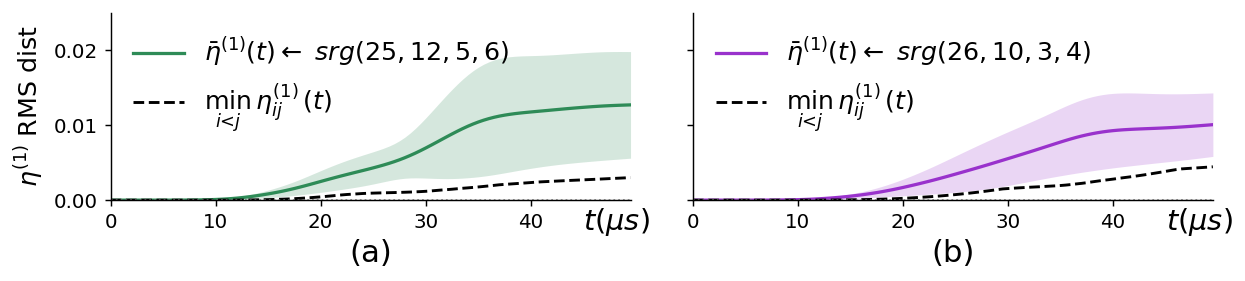

Saved figure to: figures/srg_assignment_distance_curves.pdf


In [6]:
plot_assignment_distance_curves(
    results_by_family,
    save_path="figures/srg_assignment_distance_curves.pdf",)
